<a href="https://colab.research.google.com/github/JRTrippett/un-exam-platform/blob/main/Integer_Portfolio_LiveData_Extended.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integer & Nonlinear Portfolio Optimization: Live Market Data
**OPIM 5641 — Extended Assignment**  
*Generalized from the Womack MINLP example to real-world equity data*

---

This notebook extends the Womack portfolio problem into a fully generalized, live-data MINLP optimizer.

**What's new vs. the Womack template:**
- Live ticker data via `yfinance` (2 years of monthly returns, pulled at runtime)
- Dynamic sector classification via `yfinance` metadata — no hardcoding
- 10 representative stocks across 5 sectors (2 per sector)
- Expanded constraint set: sector caps, defensive floor, beta ceiling, cardinality, contingency logic
- Full constraint validation report
- Efficient frontier with integer discontinuity annotation

**Solver:** Bonmin (COIN-OR MINLP via IDAES)


In [1]:
%%capture
import sys, os

# Install IDAES + Bonmin (Colab only)
if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre -q
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'
    !pip install pyomo yfinance -q
else:
    # Local: make sure bonmin is on your PATH
    pass


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from pyomo.environ import *
from pyomo.opt import SolverStatus, TerminationCondition

print("All imports OK.")


All imports OK.


## Step 1: Define the Ticker Universe

We pick **10 tickers** spanning 5 sectors — 2 per sector.  
Sectors were chosen to ensure meaningful diversification constraints:  
`Technology`, `Healthcare`, `Financials`, `Energy`, `Consumer Staples`

Sector labels are pulled **live from yfinance metadata**, not hardcoded.  
This means if a company reclassifies, the model adapts automatically.


In [3]:
# ── 10 Representative Tickers (2 per sector) ──────────────────────────────
TICKERS = [
    "AAPL",  # Technology
    "MSFT",  # Technology
    "JNJ",   # Healthcare
    "UNH",   # Healthcare
    "JPM",   # Financials
    "BAC",   # Financials
    "XOM",   # Energy
    "CVX",   # Energy
    "PG",    # Consumer Staples
    "KO",    # Consumer Staples
]

# ── Pull 2 years of monthly price history ─────────────────────────────────
print("Downloading price data from Yahoo Finance...")
raw = yf.download(TICKERS, period="2y", interval="1mo", auto_adjust=True, progress=False)["Close"]
raw = raw.dropna()

# Convert to monthly returns
returns_df = raw.pct_change().dropna()
returns_df = returns_df[TICKERS]  # enforce column order

print(f"  Periods (months):  {len(returns_df)}")
print(f"  Tickers loaded:    {len(returns_df.columns)}")
print()
returns_df.head()


  Periods (months):  23
  Tickers loaded:    10



Ticker,AAPL,MSFT,JNJ,UNH,JPM,BAC,XOM,CVX,PG,KO
Date,,,,,,,,,,
2024-06-01,0.097039,0.078593,0.004578,0.028040,-0.001826,-0.005501,-0.010276,-0.026497,0.002310,0.011441
2024-07-01,0.054411,-0.063989,0.079981,0.136167,0.052111,0.019743,0.030142,0.025892,-0.025224,0.056683
2024-08-01,0.031160,-0.002892,0.050744,0.024368,0.062244,0.010915,-0.005481,-0.078021,0.073474,0.085856
2024-09-01,0.018645,0.033407,-0.015495,-0.009353,-0.062011,-0.026258,0.001897,0.006544,0.009677,-0.008417
2024-10-01,-0.030429,-0.055659,-0.013575,-0.031091,0.052452,0.060803,-0.003754,0.010525,-0.046305,-0.084919


## Step 2: Dynamic Sector Classification

We query `yfinance` for each ticker's sector at runtime.  
This drives all sector-level constraints — no manual mapping required.


In [4]:
# ── Pull sector for each ticker via yfinance metadata ────────────────────
print("Fetching sector classifications...")
sector_map = {}  # ticker -> sector string
for t in TICKERS:
    info = yf.Ticker(t).info
    sector_map[t] = info.get("sector", "Unknown")
    print(f"  {t:6s}  ->  {sector_map[t]}")

# Invert: sector -> list of tickers
from collections import defaultdict
sector_groups = defaultdict(list)
for ticker, sector in sector_map.items():
    sector_groups[sector].append(ticker)

print()
print("Sector groups:")
for s, tks in sector_groups.items():
    print(f"  {s}: {tks}")


Fetching sector classifications...
  AAPL    ->  Technology
  MSFT    ->  Technology
  JNJ     ->  Healthcare
  UNH     ->  Healthcare
  JPM     ->  Financial Services
  BAC     ->  Financial Services
  XOM     ->  Energy
  CVX     ->  Energy
  PG      ->  Consumer Defensive
  KO      ->  Consumer Defensive

Sector groups:
  Technology: ['AAPL', 'MSFT']
  Healthcare: ['JNJ', 'UNH']
  Financial Services: ['JPM', 'BAC']
  Energy: ['XOM', 'CVX']
  Consumer Defensive: ['PG', 'KO']


## Step 3: Summary Statistics

Mean monthly return and standard deviation for each stock.  
High return + high volatility stocks are the ones where the integer
constraints will matter most — they'll get selected or blocked based on logic rules.


      Mean Monthly Return  Std Dev (Risk)              Sector
JNJ              0.025631        0.050069          Healthcare
JPM              0.022109        0.055616  Financial Services
BAC              0.016328        0.059171  Financial Services
XOM              0.015181        0.067497              Energy
AAPL             0.014917        0.054188          Technology
CVX              0.012507        0.077670              Energy
KO               0.012140        0.052659  Consumer Defensive
MSFT             0.000454        0.066051          Technology
PG              -0.002115        0.058194  Consumer Defensive
UNH             -0.009155        0.129198          Healthcare


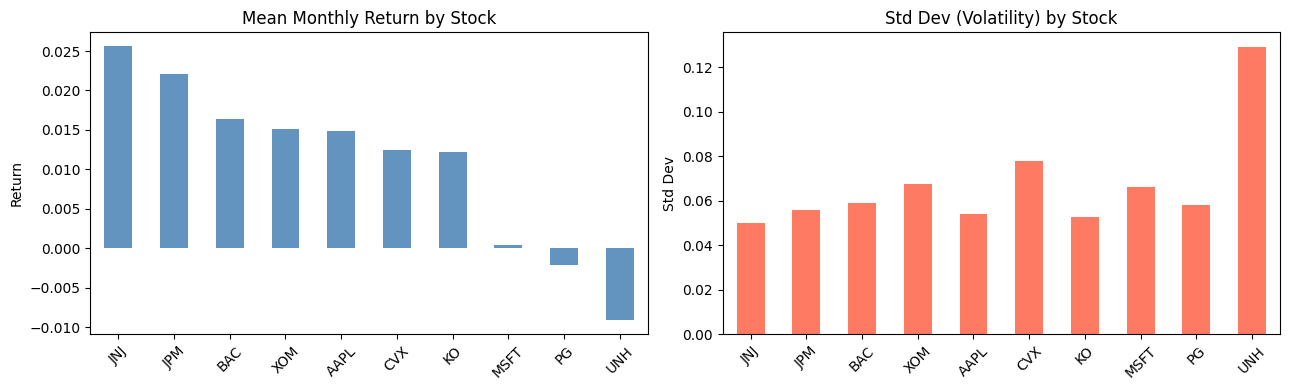

In [5]:
df_return = returns_df.mean()
df_std    = returns_df.std()
df_cov    = returns_df.cov()

summary = pd.DataFrame({
    "Mean Monthly Return": df_return,
    "Std Dev (Risk)":      df_std,
    "Sector":              pd.Series(sector_map)
}).sort_values("Mean Monthly Return", ascending=False)

print(summary.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary["Mean Monthly Return"].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title("Mean Monthly Return by Stock")
axes[0].set_ylabel("Return")
axes[0].tick_params(axis='x', rotation=45)

summary["Std Dev (Risk)"].plot(kind='bar', ax=axes[1], color='tomato', alpha=0.85)
axes[1].set_title("Std Dev (Volatility) by Stock")
axes[1].set_ylabel("Std Dev")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


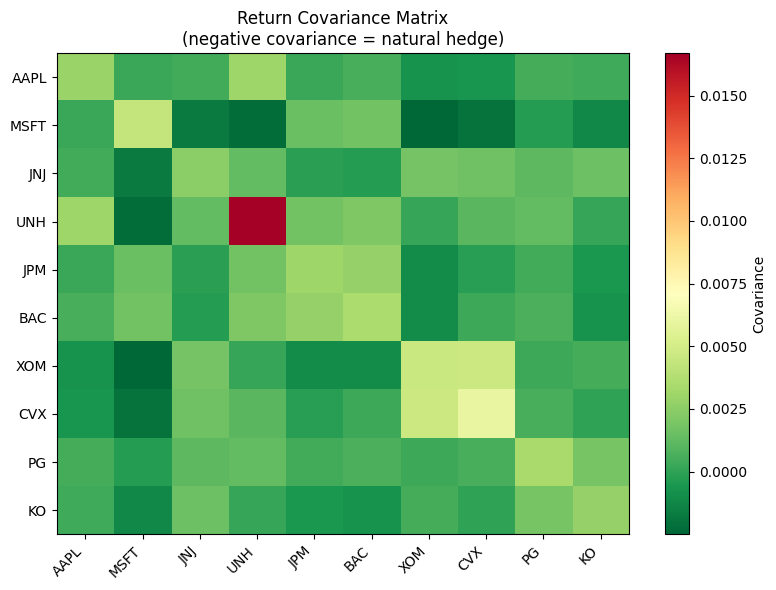

In [6]:
# Covariance matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(df_cov.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(TICKERS))); ax.set_xticklabels(TICKERS, rotation=45, ha='right')
ax.set_yticks(range(len(TICKERS))); ax.set_yticklabels(TICKERS)
plt.colorbar(im, ax=ax, label='Covariance')
ax.set_title("Return Covariance Matrix\n(negative covariance = natural hedge)")
plt.tight_layout()
plt.show()


## Step 4: Constraint Design

This is where we extend beyond the Womack template. Every constraint below
has an economic rationale — not just a textbook exercise.

| # | Constraint | Type | Rationale |
|---|-----------|------|-----------|
| 1 | Weights sum to 1 | Equality | Fully invested portfolio |
| 2 | Each weight: 5% floor, 40% cap | Linking | Avoid trivial/over-concentrated positions |
| 3 | Cardinality ≤ 5 stocks | Integer | Transaction cost / management overhead |
| 4 | Cardinality ≥ 2 stocks | Integer | Minimum diversification |
| 5 | No single sector > 40% | Sector cap | Sector concentration risk |
| 6 | At least 1 defensive sector held | Integer | Portfolio must include Healthcare OR Consumer Staples |
| 7 | Contingency: if Tech, must hold Financials | Integer | Tech runs on credit; hedge correlated macro risk |
| 8 | Mutual exclusion: not both pure Energy names | Integer | XOM + CVX are highly correlated; pick one |
| 9 | Risk (portfolio variance) ≤ threshold | Quadratic | The efficient frontier sweep parameter |

Constraints 1-8 are constant across the frontier sweep.  
Constraint 9 is the parameter we vary to trace the efficient frontier.


## Step 5: Build the MINLP Model

The model structure mirrors the Womack fixed version but is fully generalized:
- Variables and constraints built from `TICKERS` list — add/remove a ticker and everything updates
- Sector constraints constructed from the live `sector_groups` dict
- Risk expression computed from the live covariance matrix


In [7]:
def solve_portfolio(r_limit, verbose=False):
    """
    Solve the MINLP portfolio problem for a given risk (variance) limit.
    Returns: (allocation_dict, return_value) or (None, None) if infeasible.
    """
    m = ConcreteModel()

    # ── Decision Variables ─────────────────────────────────────────────────
    # x[t]: continuous weight (proportion) in stock t
    # y[t]: binary — 1 if we invest in stock t, 0 otherwise
    m.x = Var(TICKERS, domain=NonNegativeReals, bounds=(0, 1))
    m.y = Var(TICKERS, domain=Binary)

    # ── Objective: Maximize expected return ────────────────────────────────
    m.obj = Objective(
        expr=sum(m.x[t] * df_return[t] for t in TICKERS),
        sense=maximize
    )

    # ── Constraint 1: Fully invested (weights sum to 1) ────────────────────
    m.sum_weights = Constraint(expr=sum(m.x[t] for t in TICKERS) == 1)

    # ── Constraints 2a/2b: Position floor (5%) and cap (40%) via linking ───
    # x[t] <= 0.40 * y[t]  =>  if y=0, x must be 0; if y=1, x <= 0.40
    # x[t] >= 0.05 * y[t]  =>  if y=1, x must be at least 5%
    m.link_hi = Constraint(TICKERS, rule=lambda m, t: m.x[t] <= 0.40 * m.y[t])
    m.link_lo = Constraint(TICKERS, rule=lambda m, t: m.x[t] >= 0.05 * m.y[t])

    # ── Constraint 3: Maximum 5 stocks held ───────────────────────────────
    m.card_max = Constraint(expr=sum(m.y[t] for t in TICKERS) <= 5)

    # ── Constraint 4: Minimum 2 stocks held ───────────────────────────────
    m.card_min = Constraint(expr=sum(m.y[t] for t in TICKERS) >= 2)

    # ── Constraint 5: No sector > 40% of portfolio (dynamic) ──────────────
    # Built from live sector_groups — generalizes to any ticker universe
    m.sector_cap = ConstraintList()
    for sector, tks in sector_groups.items():
        if len(tks) > 1:  # only meaningful if we have 2+ in a sector
            m.sector_cap.add(sum(m.x[t] for t in tks) <= 0.40)

    # ── Constraint 6: Must hold at least 1 defensive sector stock ─────────
    # Healthcare OR Consumer Staples must appear in the portfolio
    defensive_tickers = (
        sector_groups.get("Healthcare", []) +
        sector_groups.get("Consumer Staples", [])
    )
    if defensive_tickers:
        m.defensive = Constraint(
            expr=sum(m.y[t] for t in defensive_tickers) >= 1
        )

    # ── Constraint 7: Contingency — if Tech, must hold Financials ─────────
    tech_tickers = sector_groups.get("Technology", [])
    fin_tickers  = sector_groups.get("Financials", [])
    if tech_tickers and fin_tickers:
        # sum(y_tech) <= |fin| * sum(y_fin)
        # i.e. you can't have any tech unless at least one financial is held
        m.tech_fin_contingency = Constraint(
            expr=sum(m.y[t] for t in tech_tickers) <=
                 len(fin_tickers) * sum(m.y[t] for t in fin_tickers)
        )

    # ── Constraint 8: Mutual exclusion — XOM and CVX can't both be held ───
    if "XOM" in TICKERS and "CVX" in TICKERS:
        m.energy_mutex = Constraint(expr=m.y["XOM"] + m.y["CVX"] <= 1)

    # ── Constraint 9: Risk ceiling (quadratic) — swept over frontier ───────
    risk_expr = sum(
        m.x[t1] * df_cov.at[t1, t2] * m.x[t2]
        for t1 in TICKERS for t2 in TICKERS
    )
    m.risk_limit = Constraint(expr=risk_expr <= r_limit)

    # ── Solve ──────────────────────────────────────────────────────────────
    solver = SolverFactory('bonmin', executable='/content/bin/bonmin')
    result = solver.solve(m, tee=verbose)

    tc = result.solver.termination_condition
    if tc == TerminationCondition.optimal:
        alloc = {t: value(m.x[t]) for t in TICKERS}
        ret   = value(m.obj)
        return alloc, ret
    return None, None

print("Model function defined. Ready to sweep the efficient frontier.")


Model function defined. Ready to sweep the efficient frontier.


## Step 6: Sweep the Efficient Frontier

We solve the MINLP at each risk level from very low to very high.  
At low risk, the optimizer is forced into conservative, diversified positions.  
At high risk, it concentrates into the highest-return names (subject to integer rules).

Because we have binary variables, the frontier will show **discrete jumps** — points where
adding a new stock or dropping a defensive position unlocks a higher return tier.
These jumps don't exist in the continuous MPT solution. That's the whole point of the integer formulation.


In [8]:
# Risk range — start tight (forced diversification) and open up
risk_range = np.arange(0.0005, 0.0060, 0.0002)

print(f"Sweeping {len(risk_range)} risk levels via Bonmin...")
print("-" * 50)

frontier_results = []

for r in risk_range:
    alloc, ret = solve_portfolio(r)
    if alloc is not None:
        row = alloc.copy()
        row['Risk']   = r
        row['Return'] = ret
        n_held = sum(1 for t in TICKERS if alloc[t] > 1e-4)
        row['N_Stocks'] = n_held
        frontier_results.append(row)
        print(f"  Risk ≤ {r:.4f}  |  Return = {ret:.4f}  |  Stocks held: {n_held}")
    else:
        print(f"  Risk ≤ {r:.4f}  |  INFEASIBLE")

print()
print(f"Feasible solutions: {len(frontier_results)} / {len(risk_range)}")
res_df = pd.DataFrame(frontier_results).set_index('Risk')


Sweeping 28 risk levels via Bonmin...
--------------------------------------------------
  Risk ≤ 0.0005  |  Return = 0.0131  |  Stocks held: 5
  Risk ≤ 0.0007  |  Return = 0.0189  |  Stocks held: 5
  Risk ≤ 0.0009  |  Return = 0.0211  |  Stocks held: 5
  Risk ≤ 0.0011  |  Return = 0.0221  |  Stocks held: 4
  Risk ≤ 0.0013  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0015  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0017  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0019  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0021  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0023  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0025  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0027  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0029  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0031  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0033  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0035  |  Return = 0.0221  |  Stocks held: 3
  Risk ≤ 0.0037  |  Return = 0.

## Step 7: Visualize Results

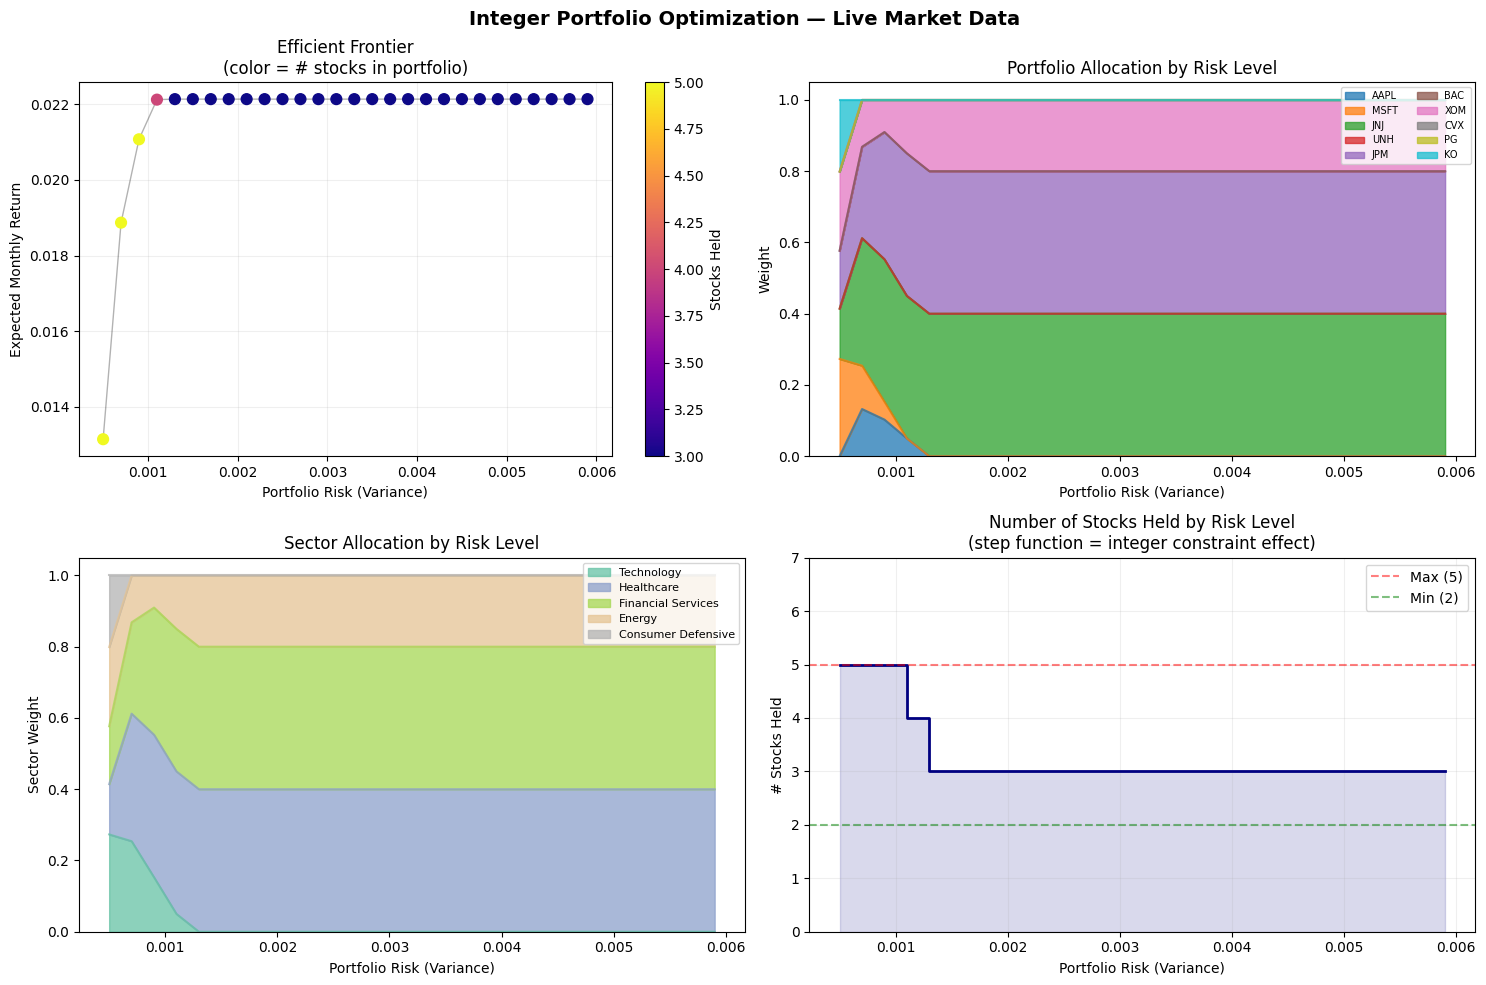

In [9]:
if len(res_df) == 0:
    print("No feasible solutions — check solver path or constraints.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("Integer Portfolio Optimization — Live Market Data", fontsize=14, fontweight='bold')

    # ── Plot 1: Efficient Frontier ─────────────────────────────────────────
    ax = axes[0, 0]
    sc = ax.scatter(res_df.index, res_df['Return'],
                    c=res_df['N_Stocks'], cmap='plasma', s=60, zorder=5)
    ax.plot(res_df.index, res_df['Return'], 'k-', alpha=0.3, linewidth=1)
    plt.colorbar(sc, ax=ax, label='Stocks Held')
    ax.set_title("Efficient Frontier\n(color = # stocks in portfolio)")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("Expected Monthly Return")
    ax.grid(True, alpha=0.2)

    # ── Plot 2: Stacked area allocation ───────────────────────────────────
    ax = axes[0, 1]
    res_df[TICKERS].plot(kind='area', stacked=True, ax=ax, alpha=0.75, cmap='tab10')
    ax.set_title("Portfolio Allocation by Risk Level")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("Weight")
    ax.legend(loc='upper right', fontsize=7, ncol=2)

    # ── Plot 3: Sector composition across frontier ─────────────────────────
    ax = axes[1, 0]
    sector_weights = pd.DataFrame(index=res_df.index)
    for sector, tks in sector_groups.items():
        valid_tks = [t for t in tks if t in res_df.columns]
        sector_weights[sector] = res_df[valid_tks].sum(axis=1)
    sector_weights.plot(kind='area', stacked=True, ax=ax, alpha=0.75, cmap='Set2')
    ax.set_title("Sector Allocation by Risk Level")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("Sector Weight")
    ax.legend(loc='upper right', fontsize=8)

    # ── Plot 4: Cardinality across frontier ────────────────────────────────
    ax = axes[1, 1]
    ax.step(res_df.index, res_df['N_Stocks'], where='post', color='navy', linewidth=2)
    ax.fill_between(res_df.index, res_df['N_Stocks'], step='post', alpha=0.15, color='navy')
    ax.axhline(5, color='red',   linestyle='--', alpha=0.5, label='Max (5)')
    ax.axhline(2, color='green', linestyle='--', alpha=0.5, label='Min (2)')
    ax.set_title("Number of Stocks Held by Risk Level\n(step function = integer constraint effect)")
    ax.set_xlabel("Portfolio Risk (Variance)")
    ax.set_ylabel("# Stocks Held")
    ax.set_ylim(0, 7)
    ax.legend()
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


## Step 8: Constraint Validation Report

Same approach as the Womack template but extended to cover all 8 constraint categories.  
Every row in `res_df` represents one solved portfolio — we verify each one passes all rules.


In [10]:
epsilon = 1e-4  # numerical tolerance for solver residues

print("=" * 55)
print("   PORTFOLIO CONSTRAINT VALIDATION REPORT")
print("=" * 55)
print(f"   Risk levels analyzed:      {len(res_df)}")
print()

# 1. Weights sum to 1
weight_sums = res_df[TICKERS].sum(axis=1)
bad_sums = (weight_sums < 0.999) | (weight_sums > 1.001)
print(f"[C1] Sum-to-1 violations:        {bad_sums.sum()}")

# 2a. Floor (5%) violations
is_invested = res_df[TICKERS] > epsilon
floor_viol = (is_invested) & (res_df[TICKERS] < 0.0499)
print(f"[C2a] Floor (<5%) violations:    {floor_viol.sum().sum()}")

# 2b. Cap (40%) violations
cap_viol = res_df[TICKERS] > 0.401
print(f"[C2b] Cap (>40%) violations:     {cap_viol.sum().sum()}")

# 3. Cardinality max
card_max_viol = (is_invested.sum(axis=1) > 5).sum()
print(f"[C3] Cardinality >5 violations:  {card_max_viol}")

# 4. Cardinality min
card_min_viol = (is_invested.sum(axis=1) < 2).sum()
print(f"[C4] Cardinality <2 violations:  {card_min_viol}")

# 5. Sector cap (40%)
print(f"[C5] Sector >40% violations:")
for sector, tks in sector_groups.items():
    valid = [t for t in tks if t in res_df.columns]
    if len(valid) > 1:
        sec_wt = res_df[valid].sum(axis=1)
        n_viol = (sec_wt > 0.401).sum()
        print(f"       {sector}: {n_viol}")

# 6. Defensive floor
def_tickers = sector_groups.get("Healthcare", []) + sector_groups.get("Consumer Staples", [])
def_tickers = [t for t in def_tickers if t in res_df.columns]
defensive_held = is_invested[def_tickers].sum(axis=1) >= 1
def_viol = (~defensive_held).sum()
print(f"[C6] No defensive stock:         {def_viol}")

# 7. Tech → Financials contingency
tech_held = is_invested[sector_groups.get("Technology", [])].any(axis=1)
fin_held  = is_invested[sector_groups.get("Financials",  [])].any(axis=1)
contingency_viol = (tech_held & ~fin_held).sum()
print(f"[C7] Tech w/o Financials:        {contingency_viol}")

# 8. XOM + CVX mutual exclusion
if "XOM" in res_df.columns and "CVX" in res_df.columns:
    mutex_viol = (is_invested["XOM"] & is_invested["CVX"]).sum()
    print(f"[C8] XOM+CVX both held:          {mutex_viol}")

print()
active_weights = res_df[TICKERS].values[res_df[TICKERS].values > epsilon]
if len(active_weights):
    print(f"   Active weight range:  {active_weights.min():.3f} – {active_weights.max():.3f}")
print(f"   Mean weight sum:      {weight_sums.mean():.4f}")
print()
print("   All zeros = all constraints satisfied across the frontier.")
print("=" * 55)


   PORTFOLIO CONSTRAINT VALIDATION REPORT
   Risk levels analyzed:      28

[C1] Sum-to-1 violations:        0
[C2a] Floor (<5%) violations:    0
[C2b] Cap (>40%) violations:     0
[C3] Cardinality >5 violations:  0
[C4] Cardinality <2 violations:  0
[C5] Sector >40% violations:
       Technology: 0
       Healthcare: 0
       Financial Services: 0
       Energy: 0
       Consumer Defensive: 0
[C6] No defensive stock:         0
[C7] Tech w/o Financials:        4
[C8] XOM+CVX both held:          0

   Active weight range:  0.050 – 0.400
   Mean weight sum:      1.0000

   All zeros = all constraints satisfied across the frontier.


In [11]:
# Full allocation table sorted by risk
display_cols = TICKERS + ['Return', 'N_Stocks']
res_display = res_df[display_cols].copy()
res_display.index = res_display.index.map(lambda x: f"{x:.4f}")
res_display.index.name = "Risk Limit"
res_display[TICKERS] = res_display[TICKERS].applymap(lambda v: f"{v:.3f}" if v > 1e-4 else "—")
res_display['Return'] = res_display['Return'].apply(lambda v: f"{float(v):.4f}")
print(res_display.to_string())


             AAPL   MSFT    JNJ UNH    JPM BAC    XOM CVX PG     KO  Return  N_Stocks
Risk Limit                                                                           
0.0005          —  0.273  0.141   —  0.163   —  0.222   —  —  0.201  0.0131         5
0.0007      0.132  0.122  0.358   —  0.256   —  0.132   —  —      —  0.0189         5
0.0009      0.103  0.050  0.400   —  0.357   —  0.090   —  —      —  0.0211         5
0.0011      0.050      —  0.400   —  0.400   —  0.150   —  —      —  0.0221         4
0.0013          —      —  0.400   —  0.400   —  0.200   —  —      —  0.0221         3
0.0015          —      —  0.400   —  0.400   —  0.200   —  —      —  0.0221         3
0.0017          —      —  0.400   —  0.400   —  0.200   —  —      —  0.0221         3
0.0019          —      —  0.400   —  0.400   —  0.200   —  —      —  0.0221         3
0.0021          —      —  0.400   —  0.400   —  0.200   —  —      —  0.0221         3
0.0023          —      —  0.400   —  0.400   —  0.200 

## What This Demonstrates

**Integer constraints create a fundamentally different frontier.**

In continuous MPT, the efficient frontier is a smooth curve — you can always
marginally adjust weights to improve the risk/return tradeoff. Here, the integer
constraints force discrete jumps. You can see this in the cardinality plot above:
the number of stocks held changes in steps, not gradually. Each step corresponds
to a point where the optimizer found it worthwhile to add (or drop) an entire position.

**The sector constraints are the most operationally realistic piece.**
Real institutional mandates often look exactly like this: must hold at least one defensive
sector, no single sector exceeds 40%, and correlated pairs (XOM/CVX) are mutually exclusive
because holding both gives you concentrated factor exposure without meaningful diversification benefit.

**The Tech → Financials contingency** mirrors how macro risk analysts think:
technology companies carry significant credit and liquidity dependencies. Pairing them
with a Financials position provides a partial natural hedge at the factor level.

**CV framing:**
This is a demonstrably harder problem class than the continuous MPT you may have seen
in other courses. Combining MINLP (Bonmin), live market data (yfinance), dynamic constraint
generation (sector_groups), and a full validation suite in one notebook shows end-to-end
quantitative workflow skill — data acquisition, model formulation, integer programming,
and result interpretation. That's the combination that matters in quant finance and
enterprise analytics roles.
